# 2.1. 물질도 파동이다

In [1]:
import numpy as np
from scipy.constants import h


def de_broglie(m, v):
    return h / (m * v)


for name, m, v in [("야구공", 0.1, 50), ("걷는 사람", 70, 1), ("자동차", 1000, 30)]:
    print(f"{name:10s}  lambda = {de_broglie(m, v):.3e} m")

야구공         lambda = 1.325e-34 m
걷는 사람       lambda = 9.466e-36 m
자동차         lambda = 2.209e-38 m


In [2]:
from scipy.constants import c, m_e

print(f"3000km/s 속도로 움직이는 전자의 파장 = {de_broglie(m_e, c * 0.01):.3e} m")

3000km/s 속도로 움직이는 전자의 파장 = 2.426e-10 m


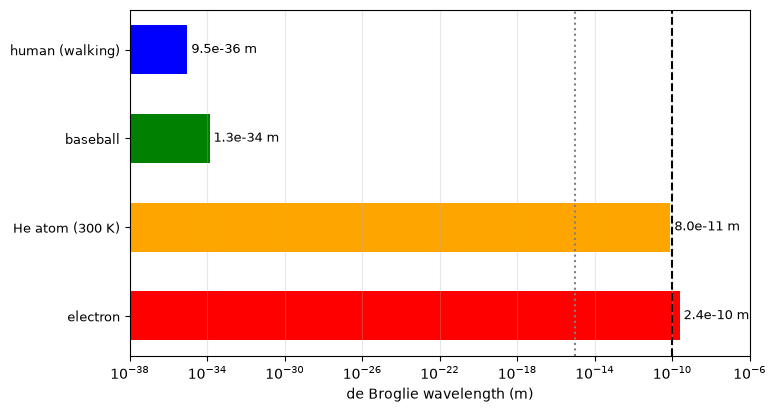

In [3]:
from scipy.constants import e
import matplotlib.pyplot as plt

items = [
    ("electron", m_e * (c * 0.01), "red"),
    ("He atom (300 K)", 6.6e-27 * 1.25e3, "orange"),
    ("baseball", 0.1 * 50, "green"),
    ("human (walking)", 70 * 1, "blue"),
]

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (name, p, col) in enumerate(items):
    lam = h / p
    ax.barh(i, lam, color=col, height=0.55)
    ax.text(lam * 1.6, i, f"{lam:.1e} m", va="center", fontsize=9)

ax.axvline(1e-10, color="black", ls="--", lw=1.5)
ax.axvline(1e-15, color="gray", ls=":", lw=1.5)

ax.set_xscale("log")
ax.set_yticks(range(len(items)))
ax.set_yticklabels([n for n, _, _ in items], fontsize=9)
ax.set_xlim(1e-38, 1e-6)
ax.set_xlabel("de Broglie wavelength (m)")
ax.grid(alpha=0.3, axis="x", which="both")
plt.show()

In [4]:
# 방법 1: 드브로이 관계식으로 계산
def de_broglie_electron(V):
    """전위차 V로 가속한 전자의 드브로이 파장"""
    p = np.sqrt(2 * m_e * e * V)  # 전자의 운동에너지 (eV) = p^2/2m
    return h / p


lam_deBroglie = de_broglie_electron(54)

# 방법 2: 회절 무늬에서 읽기
d = 215e-12  # 니켈의 원자면 간격 (m)
theta = np.deg2rad(50)  # 봉우리가 나타난 각도
lam_diffraction = d * np.sin(theta)

print(f"드브로이 관계식  : {lam_deBroglie * 1e12:.1f} pm")
print(f"회절 무늬에서    : {lam_diffraction * 1e12:.1f} pm")
print(f"오차            : {abs(lam_deBroglie - lam_diffraction) / lam_diffraction * 100:.1f} %")

드브로이 관계식  : 166.9 pm
회절 무늬에서    : 164.7 pm
오차            : 1.3 %
